# Проект: Определение стоимости автомобилей

## Введение

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. Его ключевая функция — определение рыночной стоимости автомобиля на основе его характеристик. Такая функция позволит пользователям быстро и удобно узнать цену своей машины, а компании — привлечь новых клиентов за счёт улучшенного пользовательского опыта и повышения доверия к сервису.

Для реализации этой функции необходимо построить надёжную модель машинного обучения, способную точно предсказывать стоимость автомобилей по их техническим характеристикам и комплектации.

## Цель проекта

Целью проекта является создание модели, которая будет:
- качественно предсказывать рыночную стоимость автомобиля (RMSE < 2500);
- быстро обучаться;
- обеспечивать высокую скорость предсказания.

В ходе исследования будут протестированы разные алгоритмы машинного обучения, включая LightGBM и более простые модели, чтобы найти оптимальный баланс между точностью и скоростью.

## Описание данных

Для обучения и оценки моделей используется датасет, содержащий информацию об автомобилях и их стоимости.

Входные признаки:
* DateCrawled — дата скачивания анкеты из базы
* VehicleType — тип автомобильного кузова
* RegistrationYear — год регистрации автомобиля
* Gearbox — тип коробки передач
* Power — мощность (л. с.)
* Model — модель автомобиля
* Kilometer — пробег (км)
* RegistrationMonth — месяц регистрации автомобиля
* FuelType — тип топлива
* Brand — марка автомобиля
* Repaired — была машина в ремонте или нет
* DateCreated — дата создания анкеты
* NumberOfPictures — количество фотографий автомобиля
* PostalCode — почтовый индекс владельца анкеты (пользователя)
* LastSeen — дата последней активности пользователя
  
Целевой признак:
* Price — цена (евро)

## План выполнения проекта

* [Загрузка данных](#link1)
* [Предобработка данных](#link2)
* [Исследовательский анализ](#link3)
* [Обучение моделей](#link4)
* [Общий вывод](#link5)

## Подготовка рабочего пространства

In [1]:
# установим необходимые библотеки
!pip install shap -q
!pip install phik -q
!pip install scipy==1.10.1 -q
!pip install lightgbm -q
!pip install catboost -q

In [2]:
# импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import phik
from phik import resources
import shap
from math import sqrt
import time

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder, 
    MinMaxScaler,
    StandardScaler
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

In [3]:
# импортируем функции из моего модуля
from ds_lib_tatarnikov import (
    show_plot, 
    show_pies, 
    print_corr_levels, 
    to_snake_case
)

In [4]:
# отключим лишние предупреждения
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings('ignore', message=".*Found unknown categories.*")
warnings.filterwarnings('ignore', message=".*X does not have valid feature names.*")

In [5]:
# зададим константы
RANDOM_STATE = 2025
TEST_SIZE = 0.25

In [6]:
# настройки отображения таблиц
pd.options.display.max_columns = None

<a class='anchor' id="link1"></a>
## 1 Загрузка данных

**1.1 Откроем файл с данными**

In [7]:
try:
    df = pd.read_csv('autos.csv')
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/autos.csv')

**1.2 Изучим общую информацию о датафрейме**

Выведем первые строки и общую информацию о датафрейме.

In [8]:
df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

Таблица с данными об автомобилях состоит из 354369 строк и 16 столбцов. Имеются пропуски в столбцах VehicleType, Gearbox, Model, FuelType, Repaired. Имеются аномалии (в первой строке в столбцах Power и RegistrationMonth значения 0). Данные в столбцах с датами необходимо привести в datetime.  Названия столбцов требуется привести к змеиному типу.

<a class='anchor' id="link2"></a>
## 2 Предобработка данных

**2.1 Приведение к змеинному типу**

Сделаем рабочую копию датасета и приведем названия столбцов к змеиному стилю.

In [10]:
df_prepared = df.copy()
df_prepared.columns = [to_snake_case(col) for col in df_prepared.columns]
df_prepared.head()

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


**2.2 Поиск дубликатов**

In [11]:
temp = df_prepared.duplicated().sum()
print(f"Имеется {temp} явных дубликата.")

Имеется 4 явных дубликата.


Удалим дубликаты.

In [12]:
df_prepared = df_prepared.drop_duplicates()

Поищем неявные дубликаты среди анкет. Пользователи могут выкладывать один и тот же автомобиль несколько раз с разных аккаунтов.  Поэтому отбросим из анализа на дубликаты колонки 'date_crawled', 'date_created', 'number_of_pictures', 'last_seen', которые относятся к анкетам и активности пользователя.

In [13]:
# признаки анкеты автомобиля
form_features = [
    'date_crawled',
    'date_created',
    'number_of_pictures',
    'last_seen'
]

# признаки автомобиля
auto_features = [
    'price',
    'vehicle_type',
    'registration_year',
    'gearbox',
    'power',
    'model',
    'kilometer',
    'registration_month',
    'fuel_type',
    'brand',
    'repaired',
    'number_of_pictures',
    'postal_code'
]

In [14]:
temp = df_prepared.drop(columns=form_features).duplicated().sum()
print(f"Имеется {temp} неявных дубликатов.")

Имеется 21329 неявных дубликатов.


Удалим неявные дубликаты

In [15]:
df_prepared = df_prepared.drop_duplicates(subset=auto_features)

**2.3 Обработка пропусков**

Посмотрим на количество пропусков в столбцах.

In [16]:
df_prepared.isnull().sum()

date_crawled              0
price                     0
vehicle_type          36140
registration_year         0
gearbox               19015
power                     0
model                 19023
kilometer                 0
registration_month        0
fuel_type             31902
brand                     0
repaired              68063
date_created              0
number_of_pictures        0
postal_code               0
last_seen                 0
dtype: int64

Посмотрим на уникальные значения в столбцах с пропусками.

In [17]:
for feature in ['vehicle_type', 'gearbox', 'model', 'fuel_type', 'repaired']:
    print(f'Уникальные значения в столбце "{feature}":\n{df_prepared[feature].unique()}\n')

Уникальные значения в столбце "vehicle_type":
[nan 'coupe' 'suv' 'small' 'sedan' 'convertible' 'bus' 'wagon' 'other']

Уникальные значения в столбце "gearbox":
['manual' 'auto' nan]

Уникальные значения в столбце "model":
['golf' nan 'grand' 'fabia' '3er' '2_reihe' 'other' 'c_max' '3_reihe'
 'passat' 'navara' 'ka' 'polo' 'twingo' 'a_klasse' 'scirocco' '5er'
 'meriva' 'arosa' 'c4' 'civic' 'transporter' 'punto' 'e_klasse' 'clio'
 'kadett' 'kangoo' 'corsa' 'one' 'fortwo' '1er' 'b_klasse' 'signum'
 'astra' 'a8' 'jetta' 'fiesta' 'c_klasse' 'micra' 'vito' 'sprinter' '156'
 'escort' 'forester' 'xc_reihe' 'scenic' 'a4' 'a1' 'insignia' 'combo'
 'focus' 'tt' 'a6' 'jazz' 'omega' 'slk' '7er' '80' '147' '100' 'z_reihe'
 'sportage' 'sorento' 'v40' 'ibiza' 'mustang' 'eos' 'touran' 'getz' 'a3'
 'almera' 'megane' 'lupo' 'r19' 'zafira' 'caddy' 'mondeo' 'cordoba' 'colt'
 'impreza' 'vectra' 'berlingo' 'tiguan' 'i_reihe' 'espace' 'sharan'
 '6_reihe' 'panda' 'up' 'seicento' 'ceed' '5_reihe' 'yeti' 'octavia'

В столбце 'model' много уникальных значений и заполнение относительно большого количества пропусков в этом столбце может сильно повлиять на качество модели. Предлагется строки с пропусками в этом столбце удалить.

In [18]:
df_prepared = df_prepared.dropna(subset=['model'])

Пропуски в столбце 'repaired' предлагается заполнить категорией 'Unknown'. 

In [19]:
df_prepared.loc[:, 'repaired'] = df_prepared['repaired'].fillna('unknown')

Можно предположить, что автомобили одной модели будут иметь подобные типы кузова, коробки передач, типы топлива.

Посмотрим среднее количество типов кузова на одну модель.

In [20]:
average_types = df_prepared.groupby('model')['vehicle_type'].nunique().mean()

print(f"Среднее количество типов кузова на одну модель: {average_types:.2f}")

Среднее количество типов кузова на одну модель: 4.52


Посмотрим среднее количество типов коробок передач на одну модель.

In [21]:
average_types = df_prepared.groupby('model')['gearbox'].nunique().mean()

print(f"Среднее количество типов коробок передач на одну модель: {average_types:.2f}")

Среднее количество типов коробок передач на одну модель: 1.94


Посмотрим среднее количество типов топлива на одну модель.

In [22]:
average_types = df_prepared.groupby('model')['fuel_type'].nunique().mean()

print(f"Среднее количество типов топлива на одну модель: {average_types:.2f}")

Среднее количество типов топлива на одну модель: 3.26


Автомобили одной и тойже марки часто имеют разные типы кузова, коробки передач и топлива. Заполнение пропусков в этих столбцах, например наиболее частым значением, приведет к ухудшению качества анализа и предсказательной способности модели. Удалим строки с пропусками в данных столбцах.

In [23]:
df_prepared = df_prepared.dropna(subset=['vehicle_type', 'gearbox', 'fuel_type'])

In [24]:
df_prepared.isnull().sum()

date_crawled          0
price                 0
vehicle_type          0
registration_year     0
gearbox               0
power                 0
model                 0
kilometer             0
registration_month    0
fuel_type             0
brand                 0
repaired              0
date_created          0
number_of_pictures    0
postal_code           0
last_seen             0
dtype: int64

Пропусков больше нет.

**2.4 Обработка аномалий**

На данном этапе удалим только очевидные аномалии. Более подробно изучим аномалии на этапе статистического анализа.

Посмотрим на минимальные и максималные значения в столбцах.

In [25]:
df_prepared.describe().loc[['min', 'max']]

,price,registration_year,power,kilometer,registration_month,number_of_pictures,postal_code
min,0.0,1910.0,0.0,5000.0,0.0,0.0,1067.0
max,20000.0,2018.0,20000.0,150000.0,12.0,0.0,99998.0


Имеются автомобили с ценой 0.

In [26]:
df_prepared[df_prepared['price'] == 0].head(5)

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
7,2016-03-21 18:54:38,0,sedan,1980,manual,50,other,40000,7,petrol,volkswagen,no,2016-03-21 00:00:00,0,19348,2016-03-25 16:47:58
152,2016-03-11 18:55:53,0,bus,2004,manual,101,meriva,150000,10,lpg,opel,yes,2016-03-11 00:00:00,0,27432,2016-03-12 23:47:10
579,2016-03-27 11:37:43,0,sedan,1996,manual,170,5er,150000,0,petrol,bmw,no,2016-03-27 00:00:00,0,48529,2016-03-27 11:37:43
590,2016-03-20 02:36:22,0,sedan,1997,manual,0,3er,150000,0,petrol,bmw,unknown,2016-03-20 00:00:00,0,10319,2016-04-06 04:44:44
615,2016-04-05 06:36:35,0,sedan,1998,manual,75,polo,150000,0,petrol,volkswagen,yes,2016-04-05 00:00:00,0,68766,2016-04-07 10:44:39


In [27]:
df_prepared[df_prepared['price'] == 0]['price'].count()

4542

Удалим эти автомобили из выборки.

In [28]:
df_prepared = df_prepared[df_prepared['price'] != 0]

В графе с годом регистрации значения представленны в диапазоне от 1000 до 9999. Первый автомобиль появлся в 1885 году. Год сбора данных 2016. 

Удалим строки, которые не попадают в реальный диапазон.

In [29]:
df_prepared = df_prepared[(df_prepared['registration_year'] >= 1885) & (df_prepared['registration_year'] <= 2016)]

В выборке есть строки, в которых дата регистрации автомобиля позже даты создания анкеты.

Также, если у автомобиля дата регистрации и дата создания анкеты совпадают, то это новый автомодиль и его пробег не может быть большим. Однако минимальное значение пробега в выборке 5000 км.

Удалим строки, в которых дата регистрации автомобиля позже или равна дате создания анкеты.

In [30]:
# Создадим новый столбец с годом и месяцем регистрации в формате datetime
df_prepared['registration_date'] = pd.to_datetime(
    dict(year=df_prepared['registration_year'], month=df_prepared['registration_month'].replace(0, 6), day=1) # Заменим нули в месяцах регистрации на 6
)
# Приведем тип данных в столбце с датой создания анкеты в datetime
df_prepared['date_created'] = pd.to_datetime(df_prepared['date_created'], errors='coerce')

# Оставим строки, где дата регистрации не позже даты создания анкеты
df_prepared = df_prepared[
    (df_prepared['registration_date'].dt.year < df_prepared['date_created'].dt.year) |
    (
        (df_prepared['registration_date'].dt.year == df_prepared['date_created'].dt.year) &
        (df_prepared['registration_date'].dt.month < df_prepared['date_created'].dt.month)
    )
]

В датасете представленны автомобили с мощностью от 0 до 20000.

Значение 0 можно является неявным пропуском. Заполним нули медианными значениями для каждой отдельной модели

In [31]:
df_prepared['power'] = df_prepared.groupby('model')['power'].transform(
    lambda x: x.mask(x == 0, x.median())
)

Посмотрим сколько осталось автомобилей с нулевой мощностью

In [32]:
df_prepared[df_prepared['power'] == 0]['power'].count()

1

In [33]:
df_prepared[df_prepared['power'] == 0]

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen,registration_date
234296,2016-03-30 11:39:08,3800,wagon,1978,manual,0.0,serie_1,30000,0,gasoline,land_rover,unknown,2016-03-30,0,49824,2016-03-30 11:39:08,1978-06-01


Остался один автомобиль с нулевой мощностью. Удалим его.

In [34]:
df_prepared=df_prepared[df_prepared['power'] > 0]

Посчитаем медианное значение и межквартильный разброс для мощностей двигателей для каждой отдельной модели.

Выведем статистические данные.

In [35]:
df_prepared.loc[:, 'power_q1'] = df_prepared.groupby('model')['power'].transform(lambda x: x.quantile(0.25))
df_prepared.loc[:, 'power_median'] = df_prepared.groupby('model')['power'].transform('median')
df_prepared.loc[:, 'power_q3'] = df_prepared.groupby('model')['power'].transform(lambda x: x.quantile(0.75))
df_prepared.loc[:, 'power_iqr'] = df_prepared['power_q3'] - df_prepared['power_q1']
df_prepared[['power', 'power_q1', 'power_median', 'power_q3', 'power_iqr']].describe()

,power,power_q1,power_median,power_q3,power_iqr
count,260620.000000,260620.000000,260620.000000,260620.000000,260620.000000
mean,123.738919,99.791784,115.157308,133.948977,34.157193
std,169.236416,35.547286,39.982669,46.270780,17.046622
min,1.000000,26.000000,26.000000,26.000000,0.000000
25%,80.000000,75.000000,90.000000,109.000000,20.000000
50%,114.000000,90.000000,114.000000,140.000000,35.000000
75%,150.000000,118.000000,143.000000,163.000000,47.000000
max,20000.000000,330.500000,343.000000,400.000000,143.000000


В датасете представленны автомобили с мощностью от 1 до 20000. При этом видно что у самых "слабых" моделей значение q1 = 26, а у самых "мощных" q3 = 400. 

Заменим аномальные значения медианными для каждой модели автомобиля. 

In [36]:
df_prepared.loc[:, 'power'] = df_prepared.apply(
    lambda row: row['power_median']
    if (row['power'] < (row['power_q1'] - 1.5 * row['power_iqr'])) or
       (row['power'] > (row['power_q3'] + 1.5 * row['power_iqr']))
    else row['power'],
    axis=1
)

In [37]:
df_prepared['power'].describe()

count    260620.000000
mean        117.127096
std          47.288705
min           1.000000
25%          77.000000
50%         110.000000
75%         143.000000
max         508.000000
Name: power, dtype: float64

**2.5 Приведение типов данных**

Приведем тип данных в оставшихся столбцах с датами в datetime

In [38]:
df_prepared['date_crawled'] = pd.to_datetime(df_prepared['date_crawled'], errors='coerce')
df_prepared['last_seen'] = pd.to_datetime(df_prepared['last_seen'], errors='coerce')

In [39]:
df_prepared.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 260620 entries, 2 to 354368
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   date_crawled        260620 non-null  datetime64[ns]
 1   price               260620 non-null  int64         
 2   vehicle_type        260620 non-null  object        
 3   registration_year   260620 non-null  int64         
 4   gearbox             260620 non-null  object        
 5   power               260620 non-null  float64       
 6   model               260620 non-null  object        
 7   kilometer           260620 non-null  int64         
 8   registration_month  260620 non-null  int64         
 9   fuel_type           260620 non-null  object        
 10  brand               260620 non-null  object        
 11  repaired            260620 non-null  object        
 12  date_created        260620 non-null  datetime64[ns]
 13  number_of_pictures  260620 no

**2.6 Добавление признаков**

Важно учитывать, что данные о ценах на автомобиль собирались в течение года. Автомобили с одной датой регистрации могли иметь разницу в возрасте один год на момент сбора информации. Для более точного анализа добавим столбец с возрастом автомобиля в днях на момент скачивания анкеты из базы данных.

In [40]:
df_prepared['age'] = (df_prepared['date_crawled'] - df_prepared['registration_date']).dt.days

**Промежуточный итог:**

В ходе предобработки данных датасет был подготовлен к дальнейшему анализу. Данные исследованы на наличие дубликатов - дубликаты удалены. Изучены и обработаны аномальные значения. Добавлен новый признак. Названия столбцов приведены к единому стилю. Приведены типы данных. Записи с пропусками обработаны.

<a class='anchor' id="link3"></a>
## 3 Исследовательский анализ данных


Для понятной визуализации информации запишем названия признаков на русском языке.

In [41]:
# перевод таблицы с английского на русский
eng_to_rus = {
    # Столбцы
    "date_crawled": "Дата сбора анкеты",
    "price": "Цена",
    "vehicle_type": "Тип кузова",
    "registration_year": "Год регистрации",
    "gearbox": "Коробка передач",
    "power": "Мощность (л.с.)",
    "model": "Модель",
    "kilometer": "Пробег (км)",
    "registration_month": "Месяц регистрации",
    "fuel_type": "Тип топлива",
    "brand": "Марка",
    "repaired": "Ремонт",
    "date_created": "Дата создания анкеты",
    "number_of_pictures": "Кол-во фотографий",
    "postal_code": "Почтовый индекс",
    "last_seen": "Последняя активность",
    "age": "Возраст (дни)",

    # repaired
    "yes": "Да",
    "no": "Нет",
    
    # gearbox
    "manual": "Механика",
    "auto": "Автомат",

    # vehicle_type
    "suv": "Внедорожник",
    "small": "Компактный",
    "sedan": "Седан",
    "convertible": "Кабриолет",
    "bus": "Микроавтобус",
    "wagon": "Универсал",
    "coupe": "Купе",
    "other": "Другое",

    # fuel_type
    "petrol": "Бензин (UK)",
    "gasoline": "Бензин (USA)",
    "lpg": "Газ (LPG)",
    "hybrid": "Гибрид",
    "cng": "Метан (CNG)",
    "electric": "Электро",
    
    "unknown": "Неизвестно",
}

# перевод таблицы с русского на английский
rus_to_eng = {
    # Столбцы
    "Дата сбора анкеты": "date_crawled",
    "Цена": "price",
    "Тип кузова": "vehicle_type",
    "Год регистрации": "registration_year",
    "Коробка передач": "gearbox",
    "Мощность (л.с.)": "power",
    "Модель": "model",
    "Пробег (км)": "kilometer",
    "Месяц регистрации": "registration_month",
    "Тип топлива": "fuel_type",
    "Марка": "brand",
    "Ремонт": "repaired",
    "Дата создания анкеты": "date_created",
    "Кол-во фотографий": "number_of_pictures",
    "Почтовый индекс": "postal_code",
    "Последняя активность": "last_seen",
    "Возраст (дни)": "age",

    # repaired
    "Да": "yes",
    "Нет": "no",

    # gearbox
    "Механика": "manual",
    "Автомат": "auto",

    # vehicle_type
    "Внедорожник": "suv",
    "Компактный": "small",
    "Седан": "sedan",
    "Кабриолет": "convertible",
    "Микроавтобус": "bus",
    "Универсал": "wagon",
    "Купе": "coupe",
    "Другое": "other",

    # fuel_type
    "Бензин (UK)": "petrol",
    "Бензин (USA)": "gasoline",
    "Газ (LPG)": "lpg",
    "Гибрид": "hybrid",
    "Метан (CNG)": "cng",
    "Электро": "electric",

    "Неизвестно": "unknown",
}

Создадим копию датафрейма и переведем его на русский язык. Марки и модели автомобилей запишем с заглавной буквы.

In [42]:
df_rus = df_prepared.copy()
df_rus = df_rus.drop('registration_date', axis=1)
df_rus.rename(columns=eng_to_rus, inplace=True)
df_rus = df_rus.replace(eng_to_rus)
i = 0
df_rus['Модель'] = df_rus['Модель'].str.capitalize()
df_rus['Марка'] = df_rus['Марка'].str.capitalize()
df_rus.head()

,Дата сбора анкеты,Цена,Тип кузова,Год регистрации,Коробка передач,Мощность (л.с.),Модель,Пробег (км),Месяц регистрации,Тип топлива,Марка,Ремонт,Дата создания анкеты,Кол-во фотографий,Почтовый индекс,Последняя активность,power_q1,power_median,power_q3,power_iqr,Возраст (дни)
2,2016-03-14 12:52:21,9800,Внедорожник,2004,Автомат,163.0,Grand,125000,8,Бензин (USA),Jeep,Неизвестно,2016-03-14,0,90480,2016-04-05 12:47:46,129.0,158.0,211.0,82.0,4243
3,2016-03-17 16:54:04,1500,Компактный,2001,Механика,75.0,Golf,150000,6,Бензин (UK),Volkswagen,Нет,2016-03-17,0,91074,2016-03-17 17:40:17,75.0,101.0,115.0,40.0,5403
4,2016-03-31 17:25:20,3600,Компактный,2008,Механика,69.0,Fabia,90000,7,Бензин (USA),Skoda,Нет,2016-03-31,0,60437,2016-04-06 10:17:21,68.0,75.0,86.0,18.0,2830
5,2016-04-04 17:36:23,650,Седан,1995,Механика,102.0,3er,150000,10,Бензин (UK),Bmw,Да,2016-04-04,0,33775,2016-04-06 19:17:07,118.0,150.0,170.0,52.0,7491
6,2016-04-01 20:48:51,2200,Кабриолет,2004,Механика,109.0,2_reihe,150000,8,Бензин (UK),Peugeot,Нет,2016-04-01,0,67112,2016-04-05 18:18:39,75.0,90.0,109.0,34.0,4261


**3.1 Статистический анализ**

Посмотрим статистическое описание данных.

In [43]:
df_rus.describe(include='all')

,Дата сбора анкеты,Цена,Тип кузова,Год регистрации,Коробка передач,Мощность (л.с.),Модель,Пробег (км),Месяц регистрации,Тип топлива,Марка,Ремонт,Дата создания анкеты,Кол-во фотографий,Почтовый индекс,Последняя активность,power_q1,power_median,power_q3,power_iqr,Возраст (дни)
count,260620,260620.000000,260620,260620.000000,260620,260620.000000,260620,260620.000000,260620.000000,260620,260620,260620,260620,260620.0,260620.000000,260620,260620.000000,260620.000000,260620.000000,260620.000000,260620.000000
unique,213878,NaN,8,NaN,2,NaN,249,NaN,NaN,7,39,3,103,NaN,NaN,138525,NaN,NaN,NaN,NaN,NaN
top,2016-03-24 14:49:47,NaN,Седан,NaN,Механика,NaN,Golf,NaN,NaN,Бензин (UK),Volkswagen,Нет,2016-04-03 00:00:00,NaN,NaN,2016-04-07 13:17:48,NaN,NaN,NaN,NaN,NaN
freq,6,NaN,76166,NaN,207694,NaN,21585,NaN,NaN,174024,55347,200139,10335,NaN,NaN,16,NaN,NaN,NaN,NaN,NaN
first,2016-03-05 14:06:24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-03-20 00:00:00,NaN,NaN,2016-03-05 14:15:16,NaN,NaN,NaN,NaN,NaN
last,2016-04-07 14:36:58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-04-07 00:00:00,NaN,NaN,2016-04-07 14:58:51,NaN,NaN,NaN,NaN,NaN
mean,NaN,4897.556511,NaN,2002.572999,NaN,117.127096,NaN,128350.145806,6.074733,NaN,NaN,NaN,NaN,0.0,51419.609619,NaN,99.791784,115.157308,133.948977,34.157193,4821.388462
std,NaN,4624.508173,NaN,6.227440,NaN,47.288705,NaN,36603.028331,3.537859,NaN,NaN,NaN,NaN,0.0,25766.419858,NaN,35.547286,39.982669,46.270780,17.046622,2277.356776
min,NaN,1.000000,NaN,1910.000000,NaN,1.000000,NaN,5000.000000,0.000000,NaN,NaN,NaN,NaN,0.0,1067.000000,NaN,26.000000,26.000000,26.000000,0.000000,31.000000
25%,NaN,1390.000000,NaN,1999.000000,NaN,77.000000,NaN,125000.000000,3.000000,NaN,NaN,NaN,NaN,0.0,30974.000000,NaN,75.000000,90.000000,109.000000,20.000000,3237.000000


Количество фотографий во всех строках равно нулю. Этот признак можно удалить.

Медианные значения и межквартильные размахи количественных данных находятся в реальных диапазонах. 

Все еще имеются аномальные значения в столбцах с ценой, мощностью. Подробнее изучим эти данные построив гистограммы.

Посмотрим на разнообразие марок и моделей автомобилей на рынке подержаных автомобилей.

In [44]:
len(df_rus['Марка'].unique())

39

In [45]:
len(df_rus['Модель'].unique())

249

**3.2 Визуализация статистических данных**

In [46]:
rus_cat_features = ['Тип кузова', 'Коробка передач', 'Модель', 'Тип топлива', 
                    'Марка', 'Ремонт']
rus_num_features_discrete = ['Год регистрации', 'Месяц регистрации']
rus_num_features_continuous = ['Возраст (дни)', 'Мощность (л.с.)', 'Пробег (км)']
rus_target_feature = 'Цена'

# Признаки, не относящиеся к характеристикам автомобиля:
other_features = ['Дата сбора анкеты', 'Дата создания анкеты', 'Последняя активность', 'Кол-во фотографий', 'Почтовый индекс']

Для количественных признаков с дискретными данными будем выводить столбчатые диаграммы частот и диаграммы размаха.

Для количественных признаков с непрерывными данными и целевого признака построим гистограммы и диаграммы размаха.

Для категориальных данных построим круговые диаграммы.

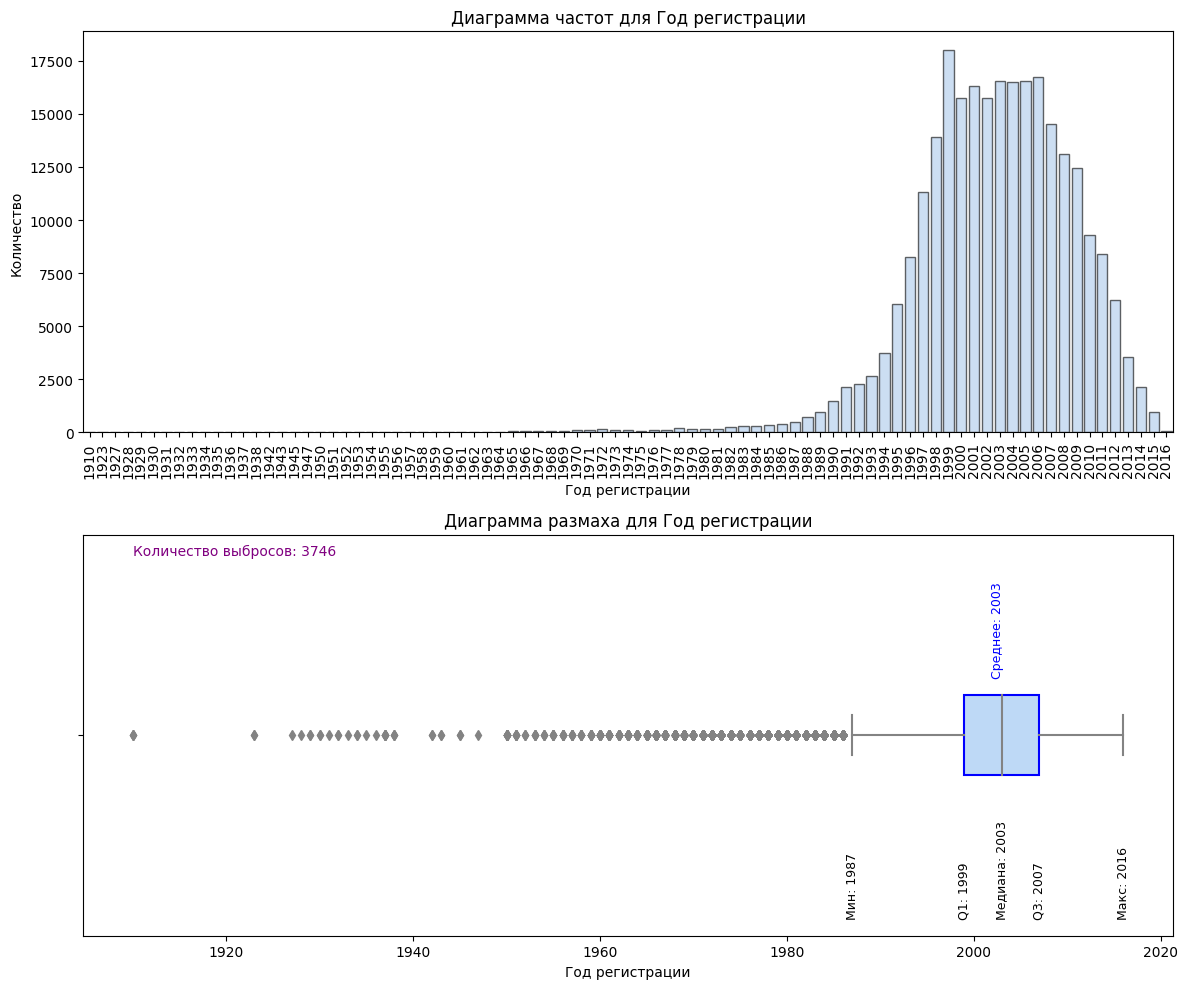

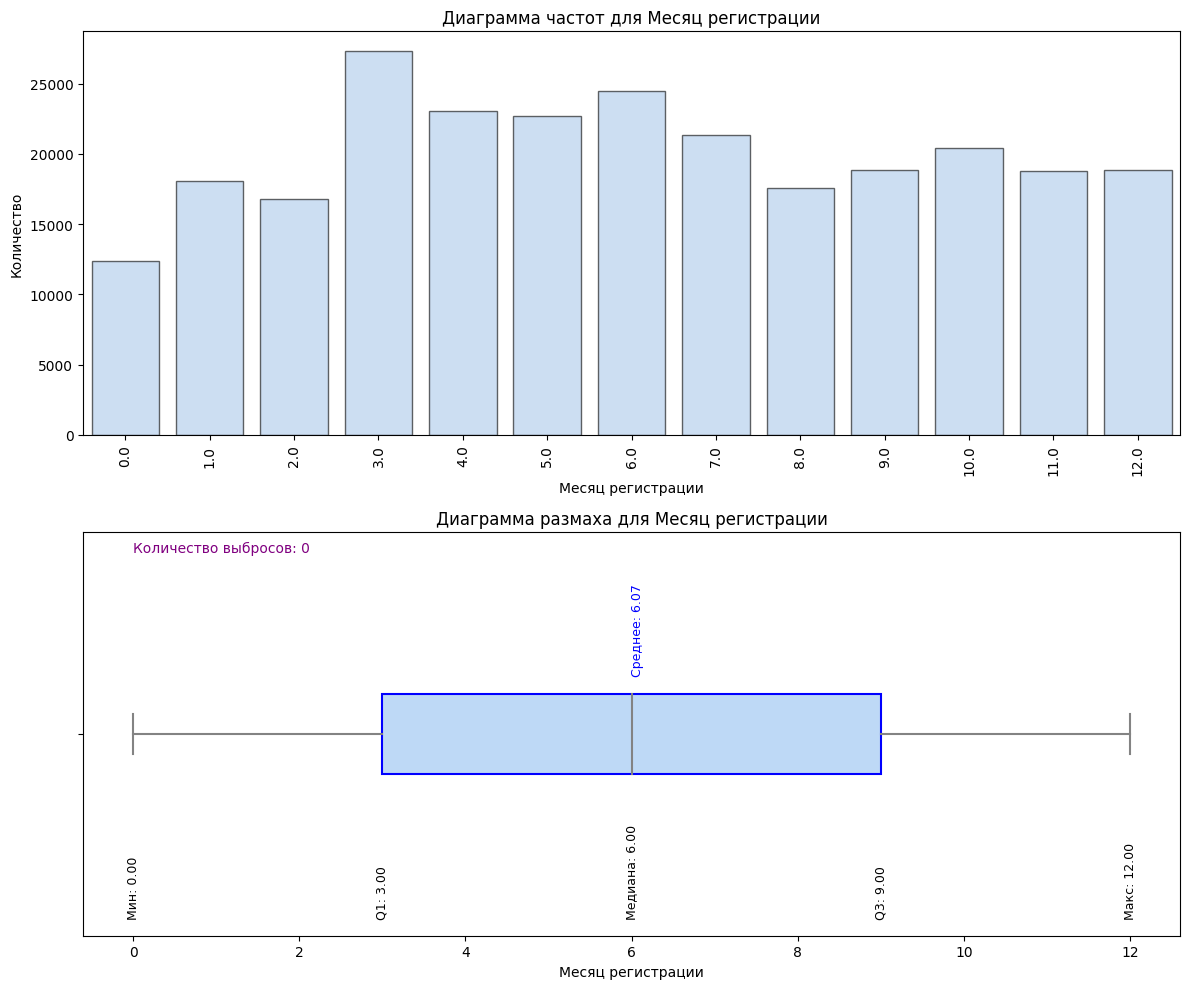

In [47]:
for feature in rus_num_features_discrete:
    show_plot(df_rus, feature, 'bars')

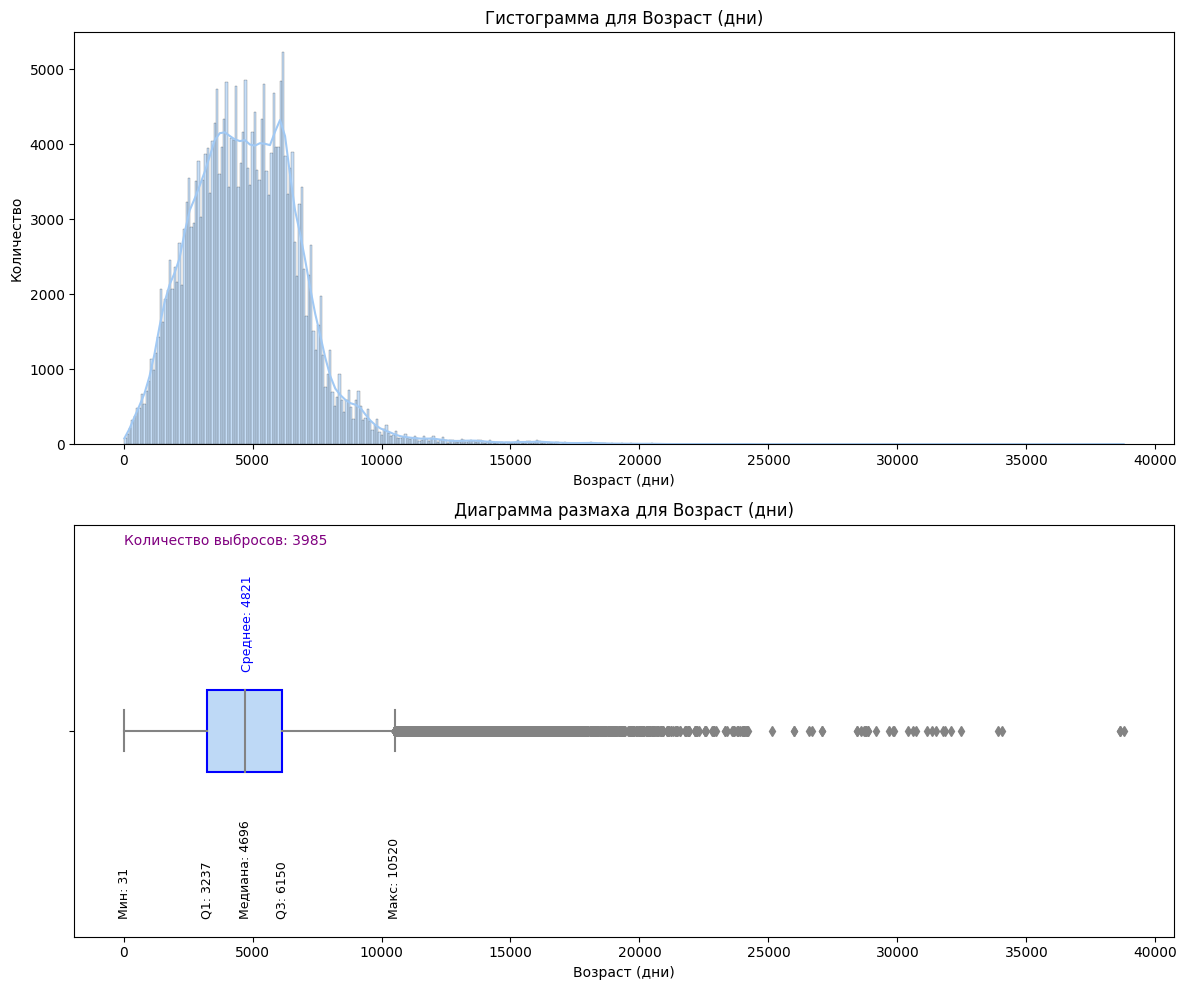

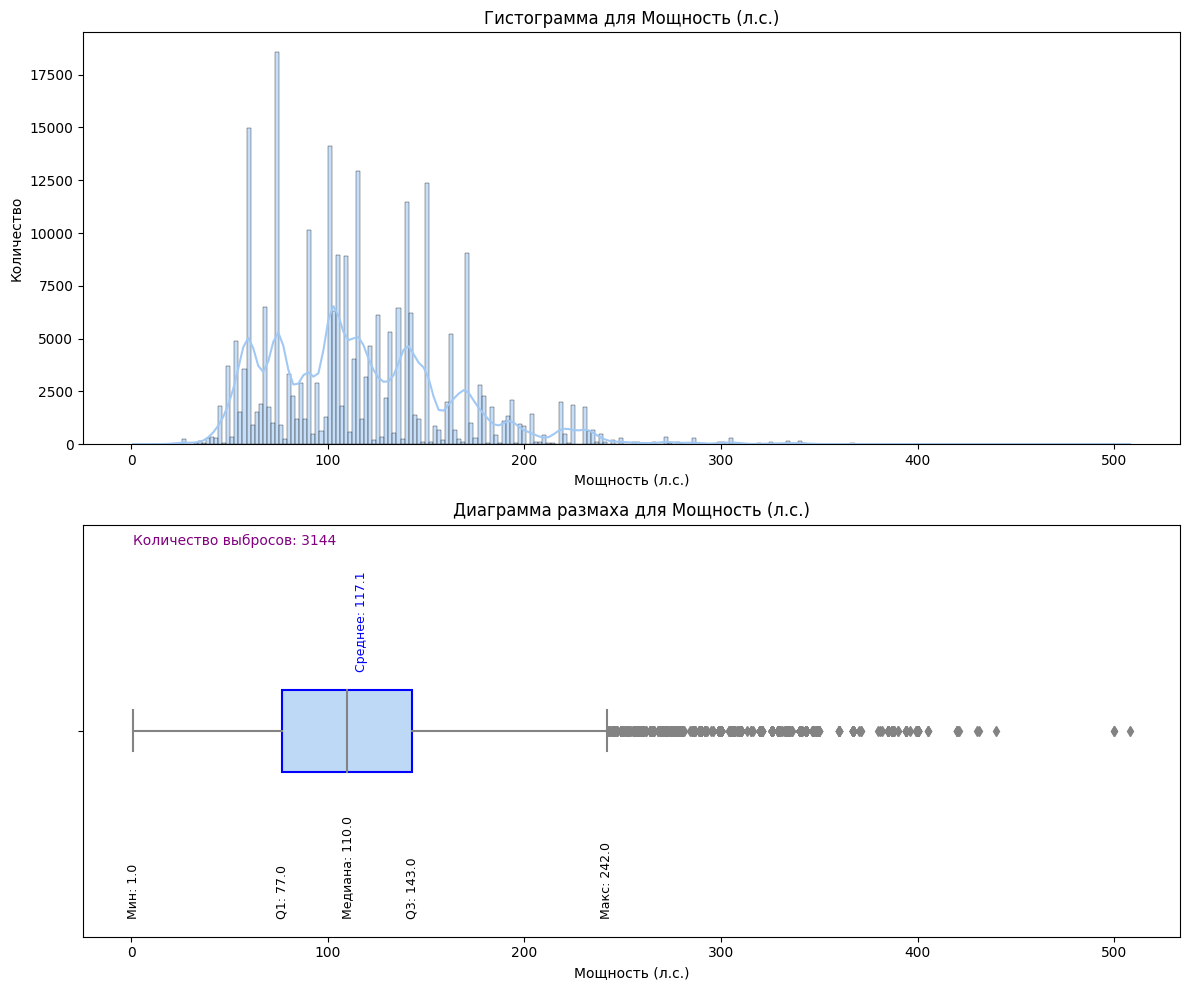

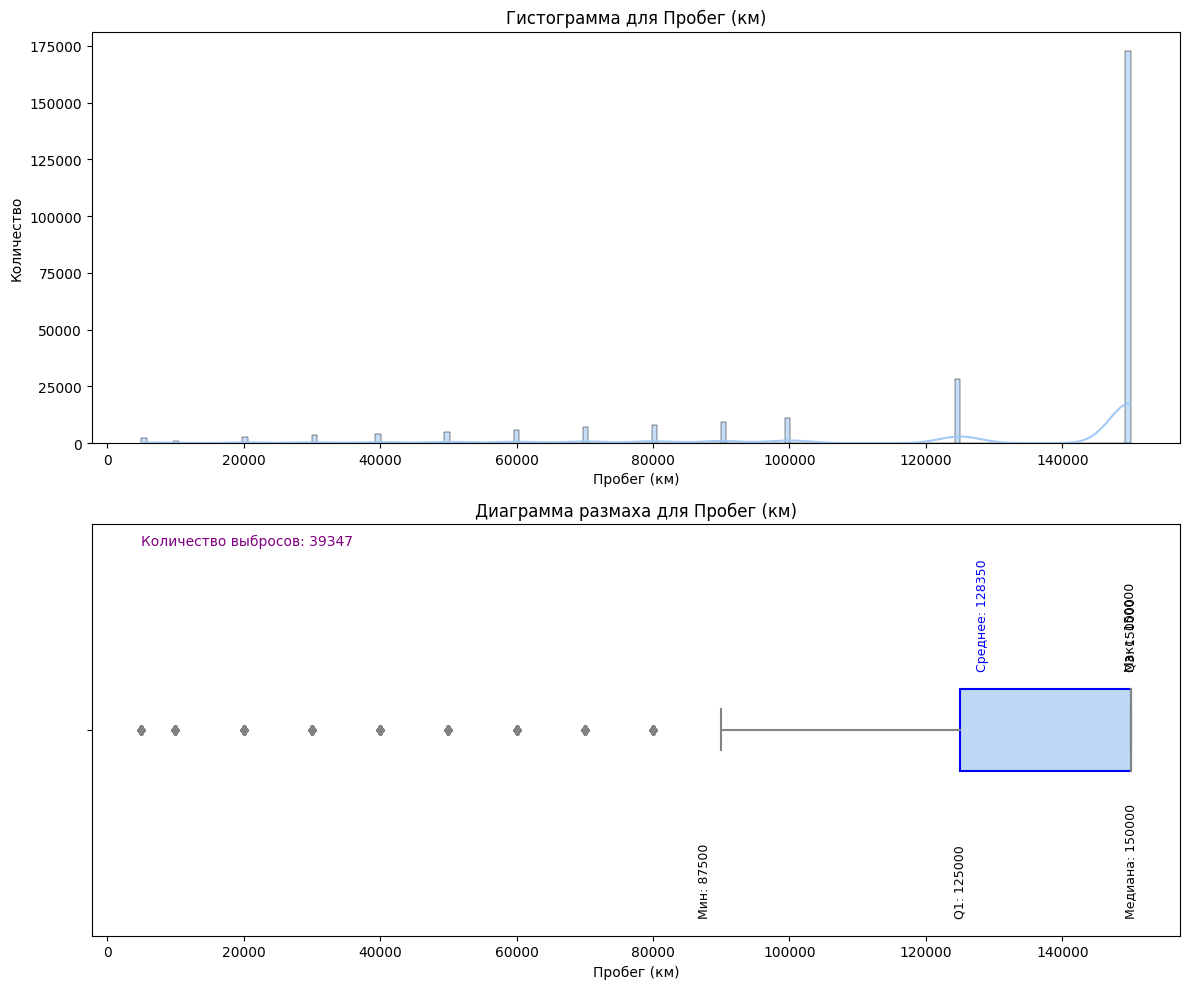

In [48]:
for feature in rus_num_features_continuous:
    show_plot(df_rus, feature)

In [49]:
# выведем уникальные значения в столбце с пробегом
df_rus['Пробег (км)'].unique()

array([125000, 150000,  90000,  30000,  70000, 100000,  60000,   5000,
        20000,  80000,  50000,  40000,  10000], dtype=int64)

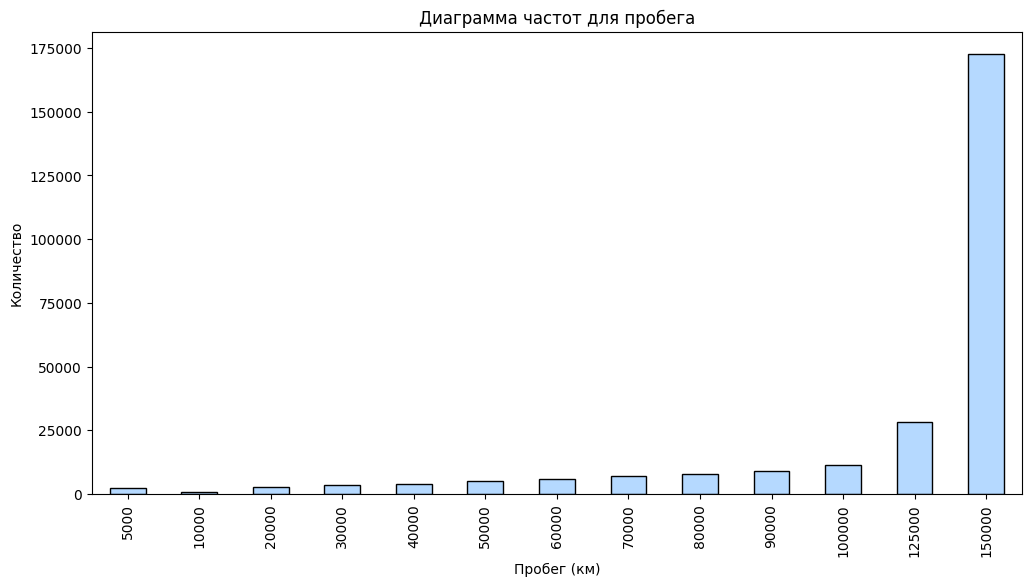

In [50]:
df_rus['Пробег (км)'].value_counts().sort_index().plot(
    kind='bar', 
    figsize=(12,6),
    color='#b5d9ff',
    edgecolor="black",
)
plt.xlabel('Пробег (км)')
plt.ylabel('Количество')
plt.title('Диаграмма частот для пробега')
plt.show()

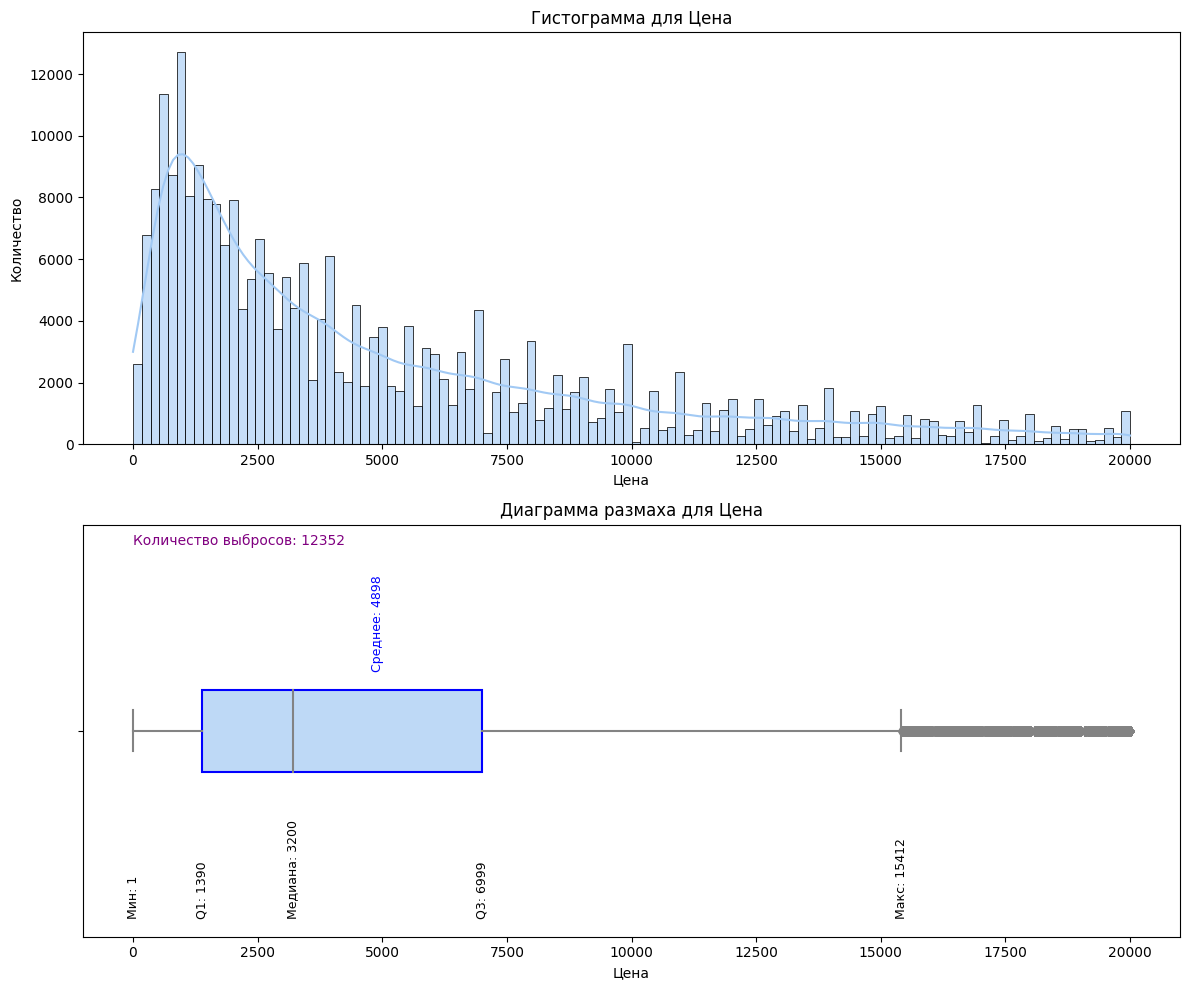

In [51]:
show_plot(df_rus, rus_target_feature)

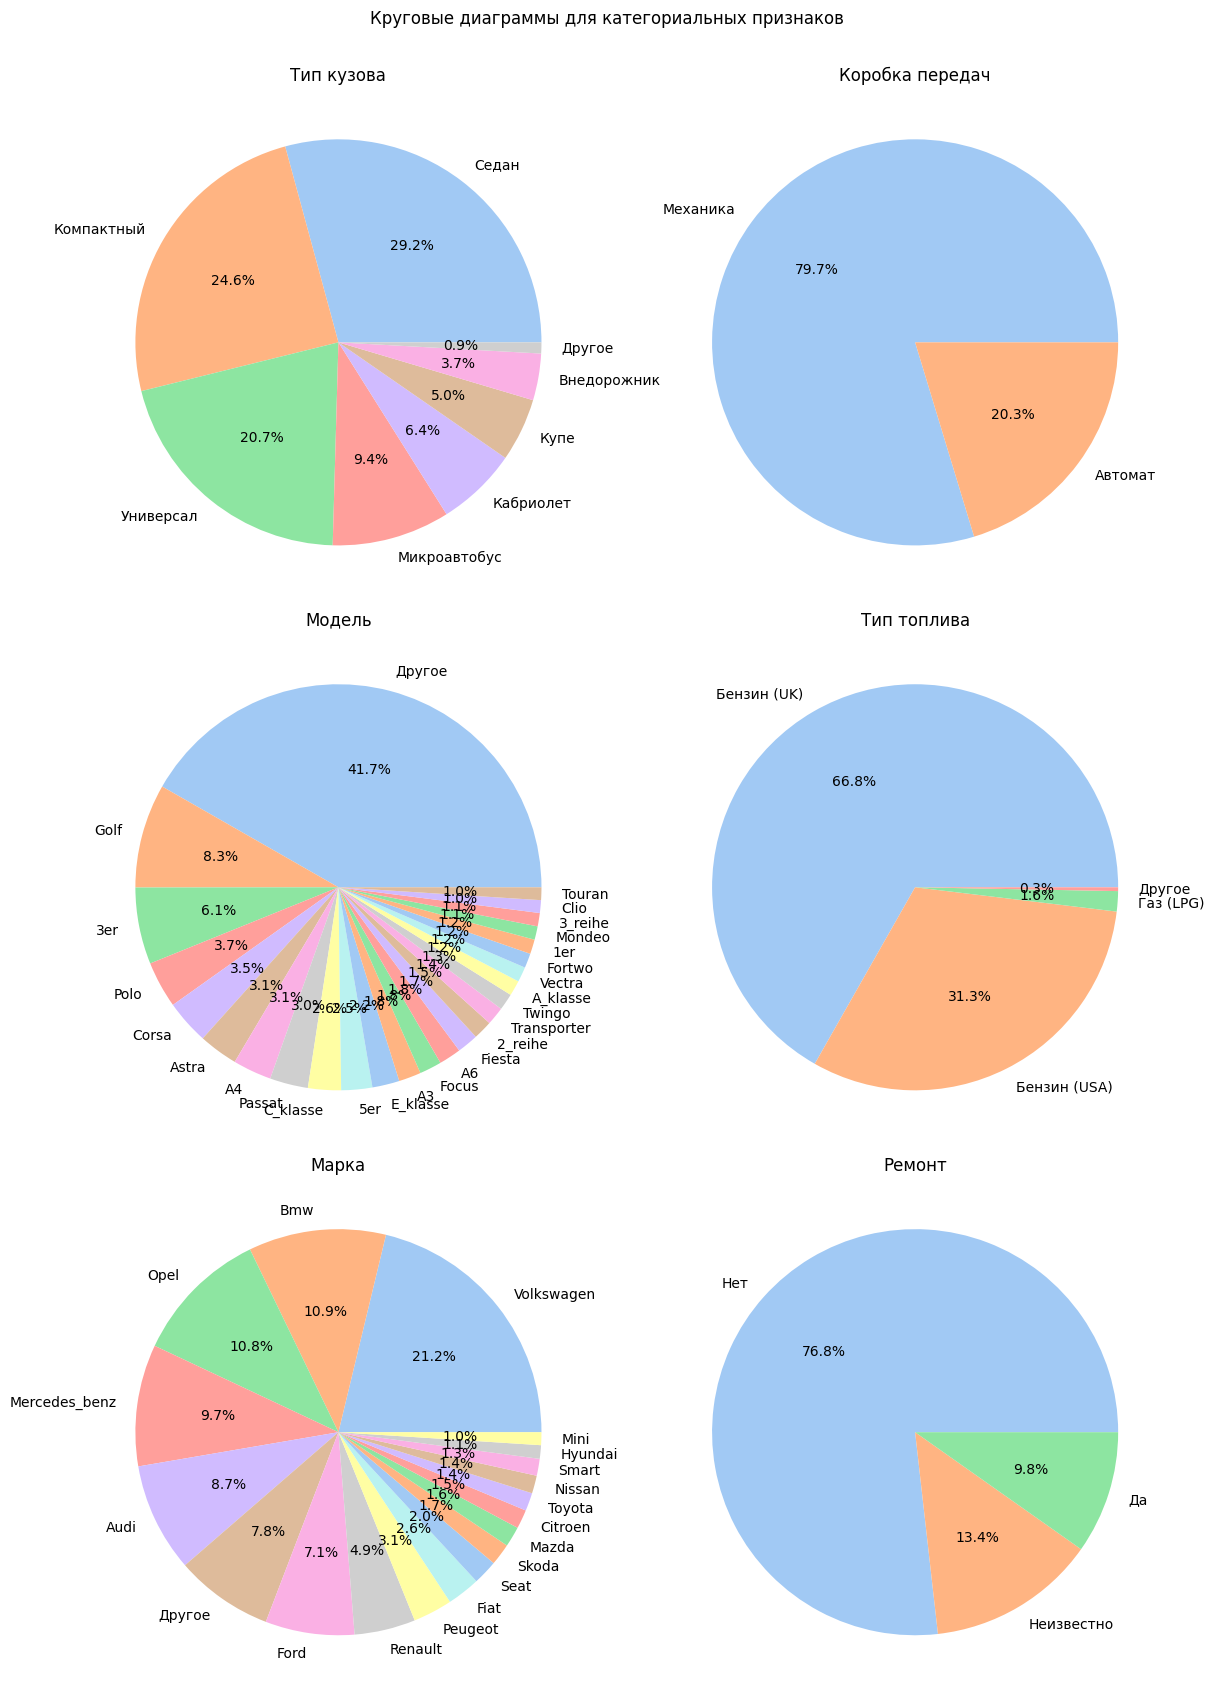

In [52]:
show_pies(df_rus, rus_cat_features)

В дополнение выведем столбчатые диаграммы для категориальных признаков.

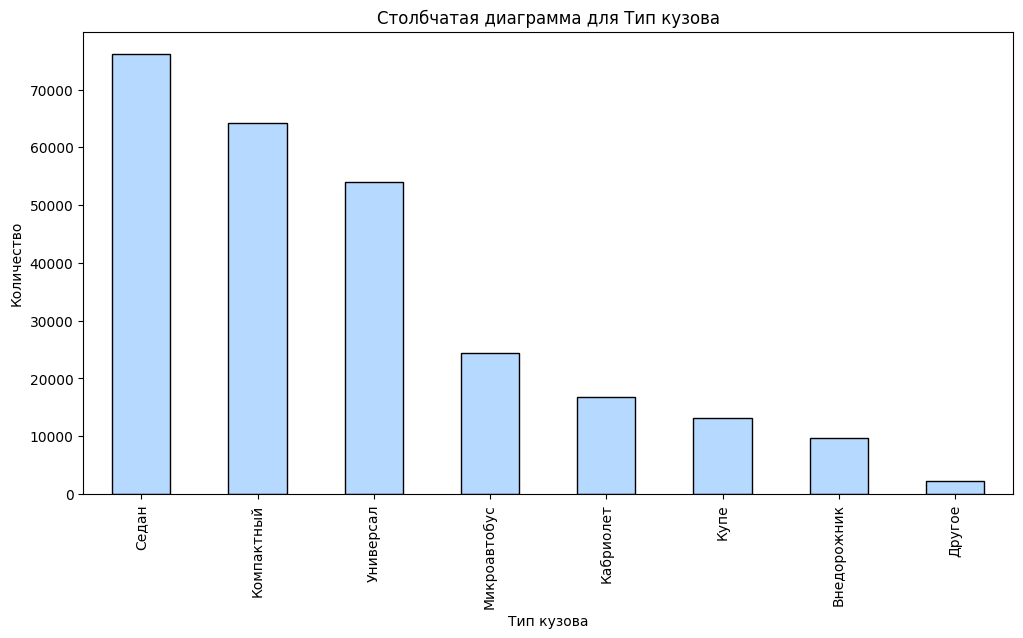

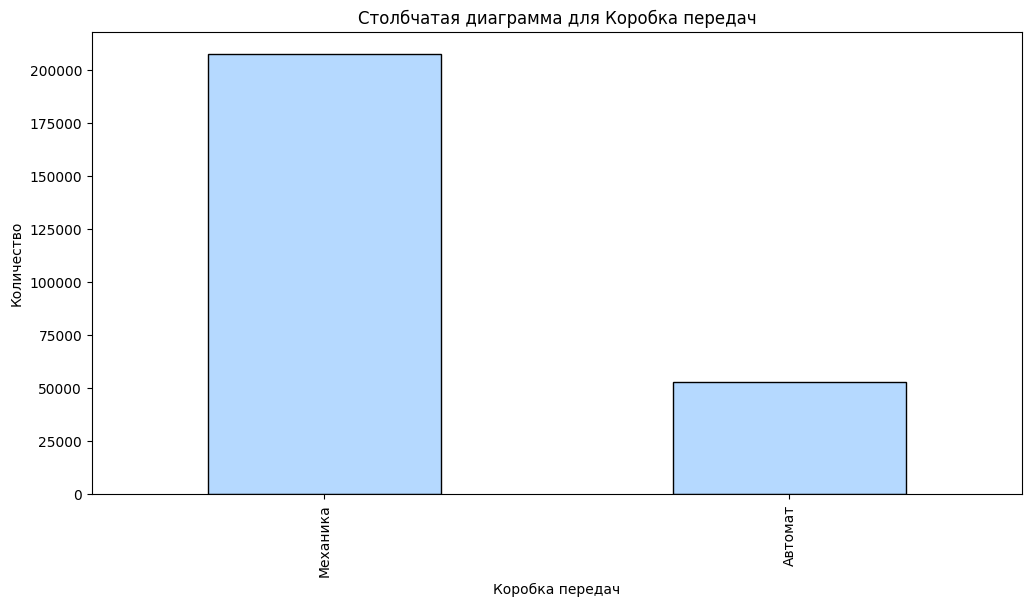

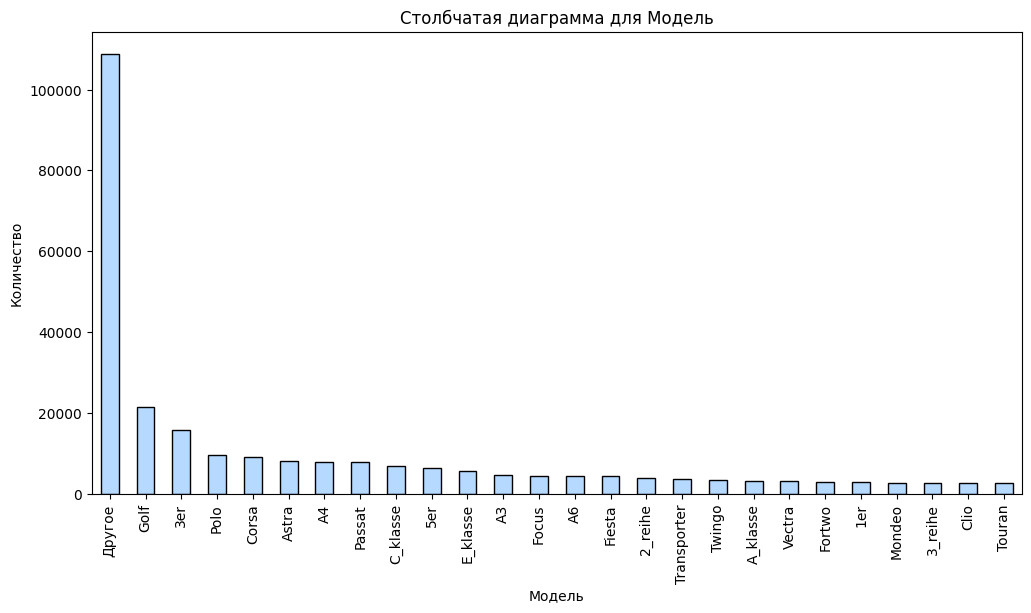

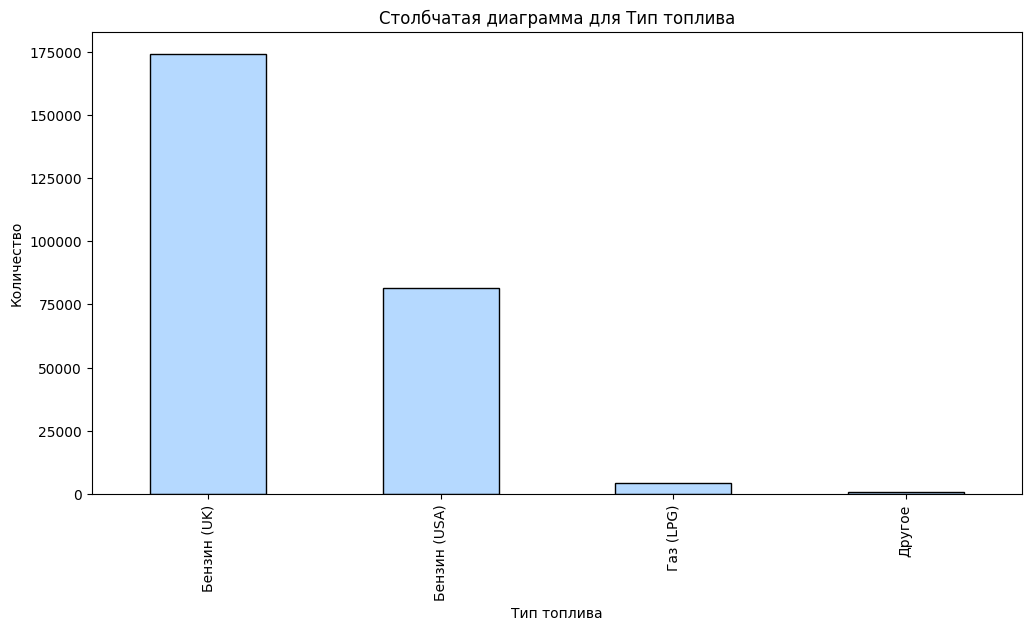

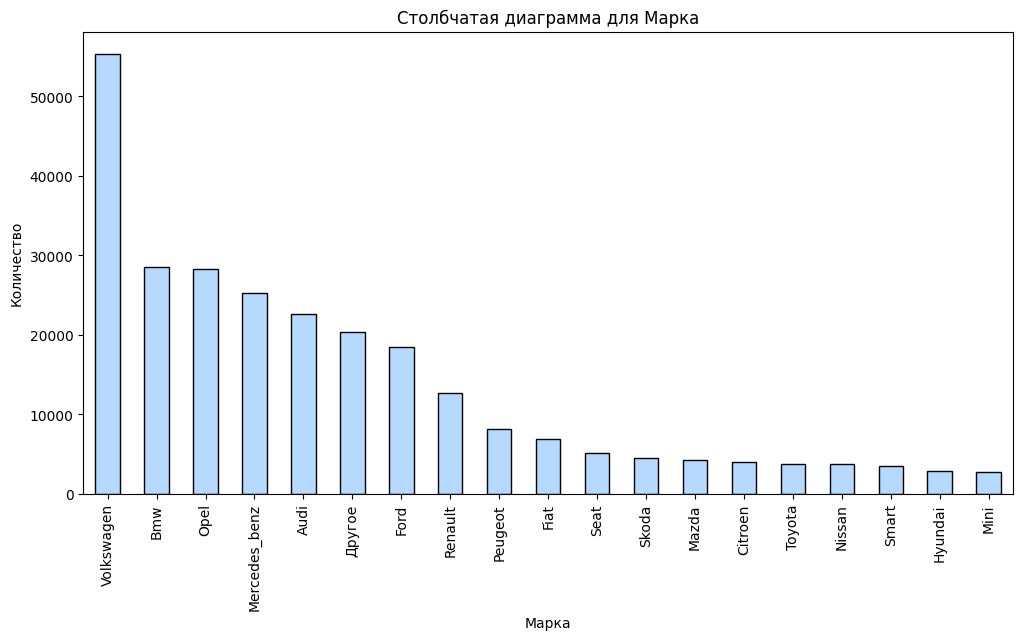

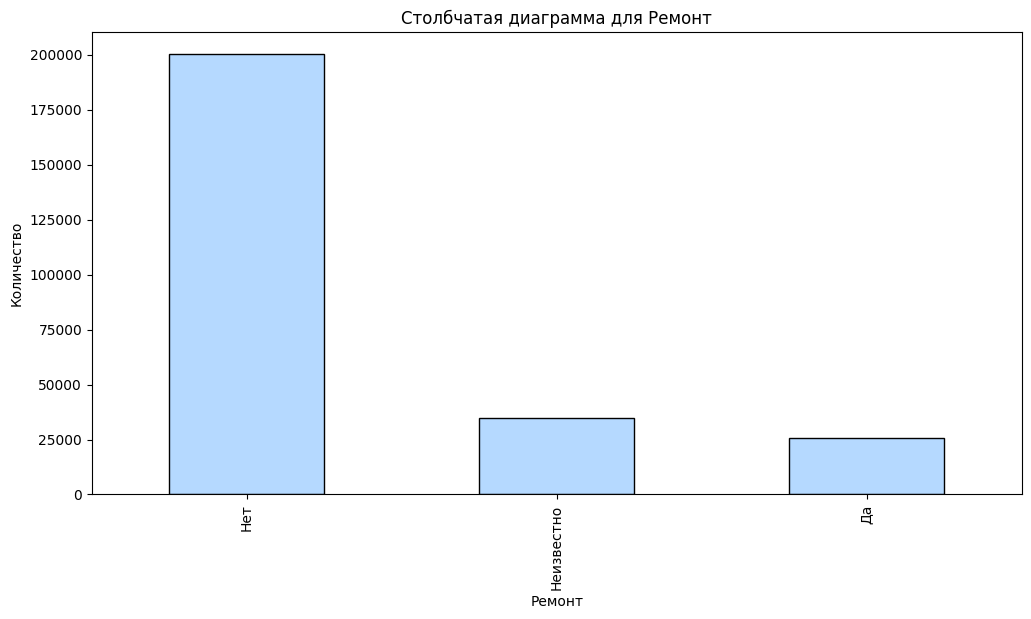

In [53]:
for feature in rus_cat_features:
    
    # Определяем редкие категории
    value_counts = df_rus[feature].value_counts(normalize=True)
    rare_categories = value_counts[value_counts < 0.01].index
    
    # Заменяем редкие категории на 'другое'
    temp_df = df_rus[feature].copy()
    temp_df[feature] = df_rus[feature].apply(lambda x: 'Другое' if x in rare_categories else x)
    
    temp_df[feature].value_counts().plot(
        kind='bar', 
        figsize=(12,6),
        color='#b5d9ff',
        edgecolor="black",
    )
    plt.xlabel(feature)
    plt.ylabel('Количество')
    plt.title(f'Столбчатая диаграмма для {feature}')
    plt.show()

**Итог статистического анализа:**

Среднее значение года регистрации и средний медианный год регистрации - 2003<br>
Межквартильный размах от 1999 до 2007 года.<br>

Средний возраст автомобиля в выборке 4801 дней (13 лет 2 месяца)<br>
Средний медианный возраст автомобиля 4685 дней (12 лет 10 месяцев)<br>

Месяцы регистрации имеют равномерное распределение.<br>

Средняя мощность двигателя 121 л.с. <br>
Cредняя медианная мощность 113 л.с.<br>
Межквартильный размах от 77 л.с. до 150 л.с.<br>

Пробег автомобилей предполагался как количественный непрерывный признак, но он имеет только 13 уникальных значений. Вероятно близкие значения пробега обедиены в группы.<br>

Средняя цена автомобиля 4904 евро.<br>
Средняя медианная цена 3250 евро.<br>
Межквартильный размах от 1390 евро до 6999 евро.<br>

В датафрейме представлены 39 марок и 249 моделей автомобилей.<br>
Самая популярная модель автомобиля - Volkswagen Golf.<br>
Наиболее популярные марки: Volkswagen, BMW, Opel.<br>

Более 90% рынка подержанных автомобилей состовляют автомобили с бензиновыми двигателями.<br>
Наиболее популярные типы кузовов: седан, компактный, универсал.<br>
Наиболее популярная коробка передач - механическая.<br>
90% автомобилей не были в ремонте.

**3.3 Корреляционный анализ данных**

In [54]:
#количественные непрерывные признаки
num_continuous_features = rus_num_features_continuous+[rus_target_feature]

In [55]:
# Вычисляем матрицу корреляции phik для тренировочной выборки
corr_matrix = df_rus.drop(columns=other_features + ['power_q1', 'power_median', 'power_q3', 'power_iqr']).phik_matrix(interval_cols=num_continuous_features)

# Выводим матрицу
corr_matrix

,Цена,Тип кузова,Год регистрации,Коробка передач,Мощность (л.с.),Модель,Пробег (км),Месяц регистрации,Тип топлива,Марка,Ремонт,Возраст (дни)
Цена,1.000000,0.267702,0.685853,0.320249,0.466856,0.578638,0.312713,0.114098,0.256366,0.338809,0.329206,0.616318
Тип кузова,0.267702,1.000000,0.265400,0.283802,0.464256,0.918358,0.175368,0.080827,0.328093,0.607669,0.099845,0.160564
Год регистрации,0.685853,0.265400,1.000000,0.128112,0.294245,0.678292,0.643190,0.178512,0.374488,0.368404,0.301485,0.999889
Коробка передач,0.320249,0.283802,0.128112,1.000000,0.568474,0.640868,0.032845,0.038118,0.147174,0.494622,0.018805,0.084089
Мощность (л.с.),0.466856,0.464256,0.294245,0.568474,1.000000,0.845393,0.109831,0.045860,0.249910,0.559826,0.094338,0.224917
Модель,0.578638,0.918358,0.678292,0.640868,0.845393,1.000000,0.444434,0.140984,0.563776,0.998326,0.219806,0.589327
Пробег (км),0.312713,0.175368,0.643190,0.032845,0.109831,0.444434,1.000000,0.071334,0.153380,0.270453,0.218695,0.323952
Месяц регистрации,0.114098,0.080827,0.178512,0.038118,0.045860,0.140984,0.071334,1.000000,0.064622,0.082939,0.281079,0.119928
Тип топлива,0.256366,0.328093,0.374488,0.147174,0.249910,0.563776,0.153380,0.064622,1.000000,0.339525,0.055868,0.227747
Марка,0.338809,0.607669,0.368404,0.494622,0.559826,0.998326,0.270453,0.082939,0.339525,1.000000,0.134873,0.280867


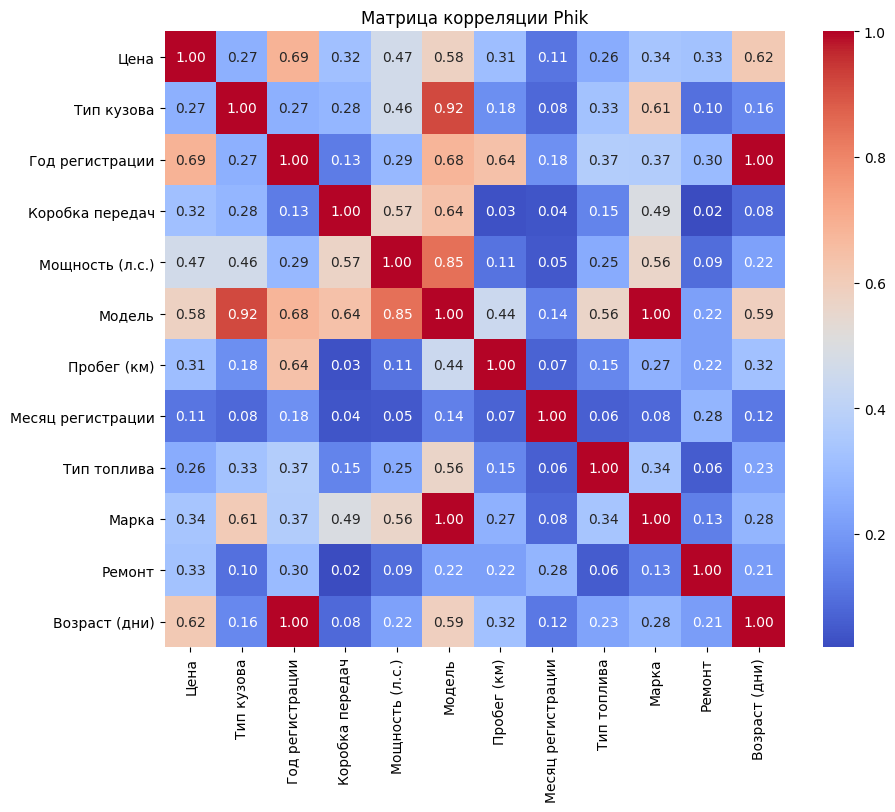

In [56]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Матрица корреляции Phik")
plt.show()

In [57]:
print_corr_levels(corr_matrix, threshold = 0.25)

[('Весьма высокая корреляция между Возраст (дни) и Год регистрации:', 1.0),
 ('Весьма высокая корреляция между Марка и Модель:', 0.998),
 ('Весьма высокая корреляция между Модель и Тип кузова:', 0.918),
 ('Высокая корреляция между Модель и Мощность (л.с.):', 0.845),
 ('Заметная корреляция между Год регистрации и Цена:', 0.686),
 ('Заметная корреляция между Год регистрации и Модель:', 0.678),
 ('Заметная корреляция между Год регистрации и Пробег (км):', 0.643),
 ('Заметная корреляция между Коробка передач и Модель:', 0.641),
 ('Заметная корреляция между Возраст (дни) и Цена:', 0.616),
 ('Заметная корреляция между Марка и Тип кузова:', 0.608),
 ('Заметная корреляция между Возраст (дни) и Модель:', 0.589),
 ('Заметная корреляция между Модель и Цена:', 0.579),
 ('Заметная корреляция между Коробка передач и Мощность (л.с.):', 0.568),
 ('Заметная корреляция между Модель и Тип топлива:', 0.564),
 ('Заметная корреляция между Марка и Мощность (л.с.):', 0.56),
 ('Умеренная корреляция между Короб

**Итог корреляционного анализа:**

Целевой признак имеет:

Заметную корреляцию с возрастом и моделью

Умеренную корреляцию с мощностью, маркой, пробегом

Слабую корреляцию с фактом ремонта, коробкой передач, типом кузова и типом топлива.

Имеется весьма высокая корреляция между маркой и моделью автомобиля, что вполне логично.

Проверим наличие автомобилей с одинаковыми названиями марок у разных производителей.

In [58]:
for model, group in df_prepared.groupby('model'):
    unique_types = group['brand'].dropna().unique()
    if len(unique_types) > 1:
        print(f"{model}: {unique_types}")

1_reihe: ['mazda' 'peugeot']
3_reihe: ['mazda' 'peugeot']
5_reihe: ['mazda' 'peugeot']
defender: ['land_rover' 'rover']
discovery: ['land_rover' 'rover']
freelander: ['land_rover' 'rover']
grand: ['jeep' 'suzuki' 'chrysler']
matiz: ['chevrolet' 'daewoo']
other: ['mercedes_benz' 'volkswagen' 'honda' 'mitsubishi' 'opel' 'suzuki'
 'lancia' 'mazda' 'nissan' 'toyota' 'chevrolet' 'renault' 'peugeot' 'kia'
 'citroen' 'fiat' 'ford' 'chrysler' 'bmw' 'hyundai' 'audi' 'jaguar'
 'skoda' 'rover' 'smart' 'saab' 'porsche' 'volvo' 'mini' 'alfa_romeo'
 'trabant' 'lada' 'daewoo' 'jeep' 'daihatsu' 'seat' 'subaru' 'dacia'
 'land_rover']


Предлагается объединить эти признаки добавив к названию марки название модели.

In [59]:
df_prepared['model'] = df_prepared['brand'].astype(str) + '_' + df_prepared['model'].astype(str)

In [60]:
df_prepared['model'].sample(5)

77621       subaru_forester
142733    volkswagen_passat
301898        skoda_octavia
163654          nissan_note
107949      chevrolet_other
Name: model, dtype: object

**Промежуточный итог:**

В ходе проведения исследовательского анализа данных был проведен статистический и корреляционный анализ данных. 

Распределение данных визуализировано. 

<a class='anchor' id="link4"></a>
## 4 Обучение моделей

Отберем признаки для обучения модели.

In [61]:
important_features = ['age', 'model', 'power', 'kilometer', 'repaired', 'gearbox', 'vehicle_type', 'fuel_type', 'price']

In [62]:
df_prepared = df_prepared[important_features]

In [63]:
df_prepared 

,age,model,power,kilometer,repaired,gearbox,vehicle_type,fuel_type,price
2,4243,jeep_grand,163.0,125000,unknown,auto,suv,gasoline,9800
3,5403,volkswagen_golf,75.0,150000,no,manual,small,petrol,1500
4,2830,skoda_fabia,69.0,90000,no,manual,small,gasoline,3600
5,7491,bmw_3er,102.0,150000,yes,manual,sedan,petrol,650
6,4261,peugeot_2_reihe,109.0,150000,no,manual,convertible,petrol,2200
...,...,...,...,...,...,...,...,...,...
354360,3989,bmw_3er,150.0,150000,no,manual,wagon,gasoline,3999
354362,4340,seat_leon,225.0,150000,yes,manual,sedan,petrol,3200
354366,5848,smart_fortwo,61.0,125000,no,auto,convertible,petrol,1199
354367,7323,volkswagen_transporter,102.0,150000,no,manual,bus,gasoline,9200


Проведем обучение пяти моделей с подбором гиперпараметров и сравним скорость обучения, скорость и качество предсказаний.

Возьмем две модели с градиентным бустингом (LightGBM и CatBoost), и две модели попроще (LinearRegression и RandomForestRegressor).

**4.1 Пайплайн для подготовки данных**

Создадим пайплайн для подготовки данных. 

В пайплайне проведем :
* масштабирование количественных признаков
* кодирование категориальных признаков. Для номинальных категориальных признков будем использовать кодировщик ОНЕ
* обработку пропусков через SimpleImputer.

In [64]:
# Категориальные признаки номинальные:
ohe_columns = ['model', 'repaired', 'gearbox', 'vehicle_type', 'fuel_type']
# Количественные признаки:
num_columns = ['age', 'power', 'kilometer']
# Целевой признак
target_feature = 'price'

In [65]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
        )
    ]
)

In [66]:
# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [67]:
# создаем итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline(
    [
        ('preprocessor', 
         data_preprocessor
        ),
        ('models', 
        LinearRegression()
        )
    ]
)

In [68]:
# Делим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    df_prepared.drop(target_feature, axis=1),
    df_prepared[target_feature],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE
)

**4.2 LinearRegression**

In [69]:
# Создадим сетку для перебора и гиперпараметров
param_grid = [
    {
        'models': [LinearRegression()],  
        'models__fit_intercept': [True, False],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
]

In [70]:
# Запуск GridSearchCV для поиска лучшей модели и гиперпараметров
grid = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_root_mean_squared_error',  
    n_jobs=-1  
)

start = time.time()
grid.fit(X_train, y_train)
end = time.time()


# выведем параметры и метрику лучшей модели
print('Лучшая модель и её параметры:\n    ', grid.best_params_)
print('\nМетрика RMSE для лучшей модели:', -grid.best_score_) 
print(f"Время перебора гиперпараметров модели: {end - start:.2f} секунд")

Лучшая модель и её параметры:
     {'models': LinearRegression(), 'models__fit_intercept': True, 'preprocessor__num': MinMaxScaler()}

Метрика RMSE для лучшей модели: 2611.083480768765
Время перебора гиперпараметров модели: 124.79 секунд


Модель с лучшими гиперпараметрами.

In [71]:
# Категориальный препроцессор
ohe_pipe = Pipeline(steps=[
    ('simpleImputer_ohe', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Общий препроцессор с нужными параметрами
data_preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', ohe_pipe, ohe_columns),
        ('num', 'passthrough', num_columns) 
    ],
    remainder='passthrough'
)

# Финальный пайплайн
pipe_LR = Pipeline(steps=[
    ('preprocessor', data_preprocessor),
    ('models', LinearRegression(fit_intercept=True))
])

Оценим качество модели на кросс-валидации.

In [72]:
start = time.time()
rmse_scores = -cross_val_score(pipe_LR, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
end = time.time()

LR_rmse = rmse_scores.mean()
LR_learn_time = (end - start) / 5

print(f"RMSE по фолдам: {rmse_scores}")
print(f"Среднее RMSE: {LR_rmse:.2f}, std: {rmse_scores.std():.2f}")
print(f"Время кросс-валидации модели: {end - start:.2f} секунд")
print(f"Среднее время одного этапа кросс-валидации модели: {LR_learn_time:.2f} секунд")

RMSE по фолдам: [2569.67425138 2634.32983312 2628.94478139 2599.2407824  2623.22775555]
Среднее RMSE: 2611.08, std: 23.92
Время кросс-валидации модели: 22.09 секунд
Среднее время одного этапа кросс-валидации модели: 4.42 секунд


**4.3 RandomForestRegressor**

Подбор гиперпараметров через GridSearchCV происходил очень долго, поэтому было решено подобрать параметры модели вручную с целью достичь RMSE < 2500. 

Модель с лучшими гиперпараметрами.

In [73]:
# Категориальный препроцессор
ohe_pipe = Pipeline(steps=[
    ('simpleImputer_ohe', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Общий препроцессор с нужными параметрами
data_preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', ohe_pipe, ohe_columns),
        ('num', StandardScaler(), num_columns) 
    ],
    remainder='passthrough'
)

# Финальный пайплайн
pipe_RFR = Pipeline(steps=[
    ('preprocessor', data_preprocessor),
    ('models', RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=20, max_depth=4))
])

Оценим качество модели на кросс-валидации.

In [74]:
start = time.time()
rmse_scores = -cross_val_score(pipe_RFR, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
end = time.time()

RFR_rmse = rmse_scores.mean()
RFR_learn_time = (end - start) / 5

print(f"RMSE по фолдам: {rmse_scores}")
print(f"Среднее RMSE: {RFR_rmse:.2f}, std: {rmse_scores.std():.2f}")
print(f"Время кросс-валидации модели: {end - start:.2f} секунд")
print(f"Среднее время одного этапа кросс-валидации модели: {RFR_learn_time:.2f} секунд")

RMSE по фолдам: [2504.51029899 2553.84912916 2566.94762447 2520.52706499 2550.07651699]
Среднее RMSE: 2539.18, std: 23.04
Время кросс-валидации модели: 117.78 секунд
Среднее время одного этапа кросс-валидации модели: 23.56 секунд


**4.4 CatBoost**

In [75]:
# Создадим сетку для перебора и гиперпараметров
param_grid = [
    {
        'models': [CatBoostRegressor(verbose=0, random_state=RANDOM_STATE)],
        'models__depth': [4, 6, 8],
        'models__learning_rate': [0.01, 0.1],
        'models__iterations': [500],
        'preprocessor__num': ['passthrough']
    }
]

In [76]:
# Запуск GridSearchCV для поиска лучшей модели и гиперпараметров
grid = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_root_mean_squared_error',  
    n_jobs=-1  
)

start = time.time()
grid.fit(X_train, y_train)
end = time.time()


# выведем параметры и метрику лучшей модели
print('Лучшая модель и её параметры:\n    ', grid.best_params_)
print('\nМетрика RMSE для лучшей модели:', -grid.best_score_) 
print(f"Время перебора гиперпараметров модели: {end - start:.2f} секунд")

Лучшая модель и её параметры:
     {'models': <catboost.core.CatBoostRegressor object at 0x0000020CF3244400>, 'models__depth': 8, 'models__iterations': 500, 'models__learning_rate': 0.1, 'preprocessor__num': 'passthrough'}

Метрика RMSE для лучшей модели: 1675.016519755342
Время перебора гиперпараметров модели: 231.64 секунд


Модель с лучшими гиперпараметрами.

In [77]:
CatBoost_model = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.1,
    verbose=False,
    cat_features=ohe_columns
    )

Оценим качество модели на кросс-валидации.

In [78]:
start = time.time()
rmse_scores = -cross_val_score(CatBoost_model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
end = time.time()

CatBoost_rmse = rmse_scores.mean()
CatBoost_learn_time = (end - start) / 5

print(f"RMSE по фолдам: {rmse_scores}")
print(f"Среднее RMSE: {CatBoost_rmse:.2f}, std: {rmse_scores.std():.2f}")
print(f"Время кросс-валидации модели: {end - start:.2f} секунд")
print(f"Среднее время одного этапа кросс-валидации модели: {CatBoost_learn_time:.2f} секунд")

RMSE по фолдам: [1642.75814259 1672.53822647 1693.65004522 1659.58432975 1664.53863854]
Среднее RMSE: 1666.61, std: 16.67
Время кросс-валидации модели: 272.85 секунд
Среднее время одного этапа кросс-валидации модели: 54.57 секунд


CatBoost поддерживает выполнение расчетов на GPU. Сравним скорость обучения на CPU и GPU.

In [79]:
CatBoost_model_GPU = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.1,
    task_type='GPU',
    devices='0',
    verbose=False,
    cat_features=ohe_columns
    )

Оценим качество модели на кросс-валидации.

In [80]:
start = time.time()
rmse_scores = -cross_val_score(CatBoost_model_GPU, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
end = time.time()

CatBoost_rmse_GPU = rmse_scores.mean()
CatBoost_learn_time_GPU = (end - start) / 5

print(f"RMSE по фолдам: {rmse_scores}")
print(f"Среднее RMSE: {CatBoost_rmse_GPU:.2f}, std: {rmse_scores.std():.2f}")
print(f"Время кросс-валидации модели: {end - start:.2f} секунд")
print(f"Среднее время одного этапа кросс-валидации модели: {CatBoost_learn_time_GPU:.2f} секунд")

RMSE по фолдам: [1631.62197069 1658.77089796 1683.32581861 1650.5469035  1661.6004113 ]
Среднее RMSE: 1657.17, std: 16.75
Время кросс-валидации модели: 85.63 секунд
Среднее время одного этапа кросс-валидации модели: 17.13 секунд


**4.5 LightGBM**

In [81]:
# Создадим сетку для перебора и гиперпараметров
param_grid = [
    {
        'models': [LGBMRegressor(random_state=RANDOM_STATE)],
        'models__learning_rate': [0.01, 0.1],
        'models__n_estimators': [500],
        'models__max_depth': [4, 6, 8],
        'preprocessor__num': ['passthrough']
    }
]

In [82]:
# Запуск GridSearchCV для поиска лучшей модели и гиперпараметров
grid = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_root_mean_squared_error',  
    n_jobs=-1  
)

start = time.time()
grid.fit(X_train, y_train)
end = time.time()


# выведем параметры и метрику лучшей модели
print('Лучшая модель и её параметры:\n    ', grid.best_params_)
print('\nМетрика RMSE для лучшей модели:', -grid.best_score_) 
print(f"Время перебора гиперпараметров модели: {end - start:.2f} секунд")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006675 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1042
[LightGBM] [Info] Number of data points in the train set: 195465, number of used features: 290
[LightGBM] [Info] Start training from score 4896.024547
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

Модель с лучшими гиперпараметрами.

In [83]:
# Категориальный препроцессор
ohe_pipe = Pipeline(steps=[
    ('simpleImputer_ohe', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Общий препроцессор с нужными параметрами
data_preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', ohe_pipe, ohe_columns),
        ('num', 'passthrough', num_columns) 
    ],
    remainder='passthrough'
)

# Финальный пайплайн
pipe_LGBM = Pipeline(steps=[
    ('preprocessor', data_preprocessor),
    ('models', LGBMRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    verbose=-1,
    random_state=RANDOM_STATE
    ))
])

Оценим качество модели на кросс-валидации.

In [84]:
start = time.time()
rmse_scores = -cross_val_score(pipe_LGBM, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
end = time.time()

LGBM_rmse = rmse_scores.mean()
LGBM_learn_time = (end - start) / 5

print(f"RMSE по фолдам: {rmse_scores}")
print(f"Среднее RMSE: {LGBM_rmse:.2f}, std: {rmse_scores.std():.2f}")
print(f"Время кросс-валидации модели: {end - start:.2f} секунд")
print(f"Среднее время одного этапа кросс-валидации модели: {LGBM_learn_time:.2f} секунд")

RMSE по фолдам: [1635.26720424 1658.54919528 1687.04592402 1648.38914322 1672.73550962]
Среднее RMSE: 1660.40, std: 18.12
Время кросс-валидации модели: 10.31 секунд
Среднее время одного этапа кросс-валидации модели: 2.06 секунд


**4.6 Анализ моделей**

Были исследованы 4 модели. Средние RMSE и время обучения одного этапа кросс-валидации приведены в таблице ниже.

In [85]:
results = pd.DataFrame(columns=['Модель', 'RMSE', 'Время этапа кросс-валидации, сек'])

results.loc[len(results)] = ['LinearRegression', round(LR_rmse, 2), round(LR_learn_time, 2)]
results.loc[len(results)] = ['RandomForestRegressor', round(RFR_rmse, 2), round(RFR_learn_time, 2)]
results.loc[len(results)] = ['CatBoost', round(CatBoost_rmse, 2), round(CatBoost_learn_time, 2)]
results.loc[len(results)] = ['LightGBM', round(LGBM_rmse, 2), round(LGBM_learn_time, 2)]

results

,Модель,RMSE,"Время этапа кросс-валидации, сек"
0,LinearRegression,2611.08,4.42
1,RandomForestRegressor,2539.18,23.56
2,CatBoost,1666.61,54.57
3,LightGBM,1660.40,2.06


Проведем обучение моделей на тренировочных выборках и предсказания на тестовой выборке. Добавим RMSE, время обучения и время предсказания в таблицу для сравнения.

In [86]:
start = time.time()
LR_model = pipe_LR.fit(X_train, y_train)
end = time.time()
LR_learn_time = end - start
print(f"Время обучения модели: {LR_learn_time:.2f} секунд")

start = time.time()
y_test_pred = LR_model.predict(X_test)
end = time.time()
LR_pred_time = end - start
LR_rmse = sqrt(mean_squared_error(y_test, y_test_pred))
print('RMSE:', round(LR_rmse, 2))
print(f"Время предсказания модели: {LR_pred_time:.2f} секунд")

Время обучения модели: 5.16 секунд
RMSE: 2656.31
Время предсказания модели: 0.25 секунд


In [87]:
start = time.time()
RFR_model = pipe_RFR.fit(X_train, y_train)
end = time.time()
RFR_learn_time = end - start
print(f"Время обучения модели: {RFR_learn_time:.2f} секунд")

start = time.time()
y_test_pred = RFR_model.predict(X_test)
end = time.time()
RFR_pred_time = end - start
RFR_rmse = sqrt(mean_squared_error(y_test, y_test_pred))
print('RMSE:', round(RFR_rmse, 2))
print(f"Время предсказания модели: {RFR_pred_time:.2f} секунд")

Время обучения модели: 29.59 секунд
RMSE: 2557.97
Время предсказания модели: 0.29 секунд


In [88]:
start = time.time()
CatBoost_model.fit(X_train, y_train, cat_features=ohe_columns)
end = time.time()
CatBoost_learn_time_GPU = end - start
print(f"Время обучения модели на GPU: {CatBoost_learn_time_GPU:.2f} секунд")

start = time.time()
y_test_pred = CatBoost_model.predict(X_test)
end = time.time()
CatBoost_pred_time = end - start
CatBoost_rmse = sqrt(mean_squared_error(y_test, y_test_pred))
print('RMSE:', round(CatBoost_rmse, 2))
print(f"Время предсказания модели: {CatBoost_pred_time:.2f} секунд")

Время обучения модели на GPU: 60.08 секунд
RMSE: 1687.86
Время предсказания модели: 0.18 секунд


In [89]:
start = time.time()
LGBM_model = pipe_LGBM.fit(X_train, y_train)
end = time.time()

LGBM_learn_time = end - start
print(f"Время обучения модели: {LGBM_learn_time:.2f} секунд")

start = time.time()
y_test_pred = LGBM_model.predict(X_test)
end = time.time()
LGBM_pred_time = end - start
LGBM_rmse = sqrt(mean_squared_error(y_test, y_test_pred))
print('RMSE:', round(LGBM_rmse, 2))
print(f"Время предсказания модели: {LGBM_pred_time:.2f} секунд")

Время обучения модели: 2.15 секунд
RMSE: 1684.44
Время предсказания модели: 0.42 секунд


In [90]:
results['RMSE тест'] = [round(LR_rmse, 2), round(RFR_rmse, 2), round(CatBoost_rmse, 2), round(LGBM_rmse, 2)]
results['Время обучения, сек'] = [round(LR_learn_time, 2), round(RFR_learn_time, 2), round(CatBoost_learn_time, 2), round(LGBM_learn_time, 2)]
results['Время предсказания, сек'] = [round(LR_pred_time, 2), round(RFR_pred_time, 2), round(CatBoost_pred_time, 2), round(LGBM_pred_time, 2)]
results

,Модель,RMSE,"Время этапа кросс-валидации, сек",RMSE тест,"Время обучения, сек","Время предсказания, сек"
0,LinearRegression,2611.08,4.42,2656.31,5.16,0.25
1,RandomForestRegressor,2539.18,23.56,2557.97,29.59,0.29
2,CatBoost,1666.61,54.57,1687.86,54.57,0.18
3,LightGBM,1660.40,2.06,1684.44,2.15,0.42


Модели показали повторяемость результатов на разных данных, что говорит о стабильности их работы.

Модель линейной регрессии показала худший результат и не попала в заданную границу RMSE.

Модель RandomForestRegressor также не выполнила требование RMSE < 2500.

Модели градиентного бустинга показали одинаково хорошую предсказательную способность с RMSE < 1700 на тестовой выборке.

Модель LightGBM обучается значительно быстрее чем CatBoost, но делает предсказания дольше.

Также модели LightGBM и CatBoost поддерживают выполнение вычислений на GPU, что может повысить скорость обучения моделей. Для пробы модель CatBoost была обучена на GPU, время обучения по сравнению с обучением на CPU уменьшилось примерно в три раза.

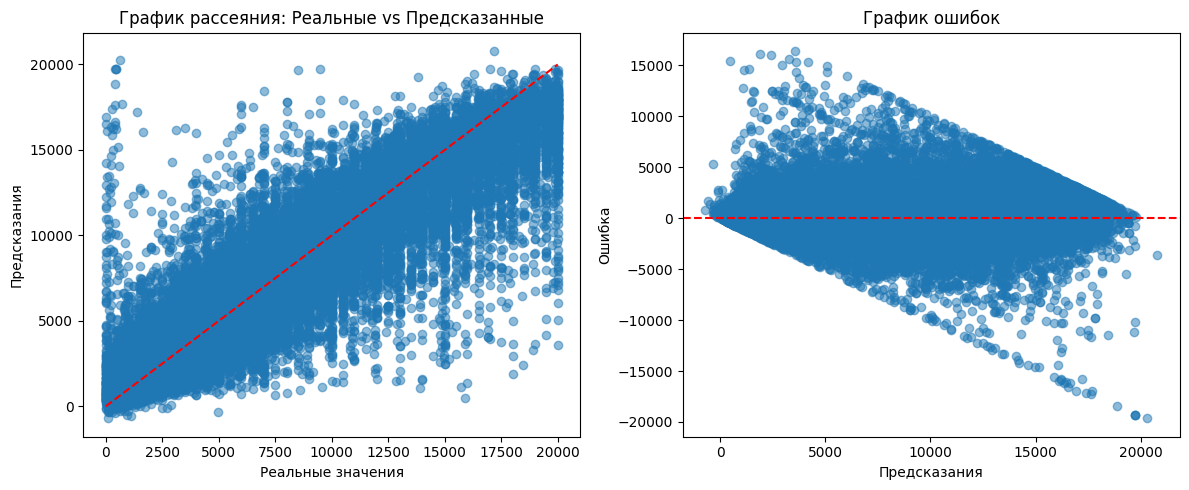

In [91]:
# График рассеяния
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # диагональ y=x
plt.xlabel('Реальные значения')
plt.ylabel('Предсказания')
plt.title('График рассеяния: Реальные vs Предсказанные')

# 2. График ошибок
plt.subplot(1,2,2)
errors = y_test - y_test_pred
plt.scatter(y_test_pred, errors, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказания')
plt.ylabel('Ошибка')
plt.title('График ошибок')

plt.tight_layout()
plt.show()

Видно, что предсказания модели плохо совпадают с реальными значениями с районе околонулевых цен. Это вероятно связано с тем, что продавцы таких автомобилей занижают стоимость своих автомобилей в анкете с какой-либо целью.

График ошибок идет сверху вниз, что говорит о том, что модель завышает предсказания для махых значений и занижает для больших.

<a class='anchor' id="link5"></a>
## Общий вывод

**Целью проекта** было построение модели, способной предсказывать цену подержанного автомобиля на основе его технических и эксплуатационных характеристик. Главными критериями для выбора модели были качество и производительность.

Для выполнения проекта был предоставлен датасет содержащий информацию о подержанных автомобилях, выставленных на продажу на онлайн платформе.

В ходе выполнения проекта данные были предобработаны. Проведен исследовательскй анализ данных, произведен отбор важных признаков.

Были протестированы различные алгоритмы машинного обучения: линейная регрессия, случайный лес и модели градиентного бустинга — LightGBM и CatBoost. Линейная регрессия показала худший результат и не удовлетворила требованиям по RMSE. Модель RandomForestRegressor продемонстрировала приемлемое качество предсказания, уложившись в заданный порог RMSE.

**Результаты**<br>
Лучшие результаты были получены от моделей градиентного бустинга. LightGBM и CatBoost достигли RMSE ≈ 1700, что значительно ниже установленного порога. При этом: 
* CatBoost — быстрее делала предсказания, 
* LightGBM обучалась быстрее CatBoost более чем в 10 раз.

Таким образом, по показателям RMSE, времени обучения и времени предсказания, модель **LightGBM** показала наиболее сбалансированные результаты и может быть рекомендована для создания сервиса по оценке рыночной стоимости автомобилей.